## IPL Score Prediction using Deep Learning


In the fast-paced world of IPL, where every run and decision can change the outcome of a match, predicting scores in real time has become both exciting and valuable. Deep learning, with its ability to process massive amounts of historical and live match data, is revolutionizing the way fans, analysts and even teams anticipate results. By uncovering complex patterns that humans or traditional methods might miss, deep learning offers highly accurate score forecasts, making it a powerful tool for enhancing the thrill and strategy of the game.

## 1. Installing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading the Dataset

The dataset contains data from 2008 to 2017 and contains features like venue, date, batting and bowling team, names of batsman and bowler, wickets and more. We will load the IPL cricket data from CSV files into pandas DataFrames to explore and prepare for modeling.

In [7]:
dataset = "https://raw.githubusercontent.com/itsluckysharma01/Datasets/refs/heads/main/ipl_data.csv"

ipl = pd.read_csv(dataset)
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


## 3. Exploratory Data Analysis


In [9]:
ipl.shape

(76014, 15)

In [10]:
ipl.tail(6)

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
76008,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,120,7,19.2,40,0,40,12,129
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129
76013,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,129,8,19.6,47,1,47,13,129


In [12]:
## Total unique venues

ipl['venue'].nunique()

35

In [ ]:
# total unique Teams

ipl['bat_team'].nunique()
ipl['bowl_team'].nunique()

14

C:\Users\PANDIT JI\AppData\Local\Temp\ipykernel_12636\920273787.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = matches_count.values, y=matches_count.index, palette='rainbow')


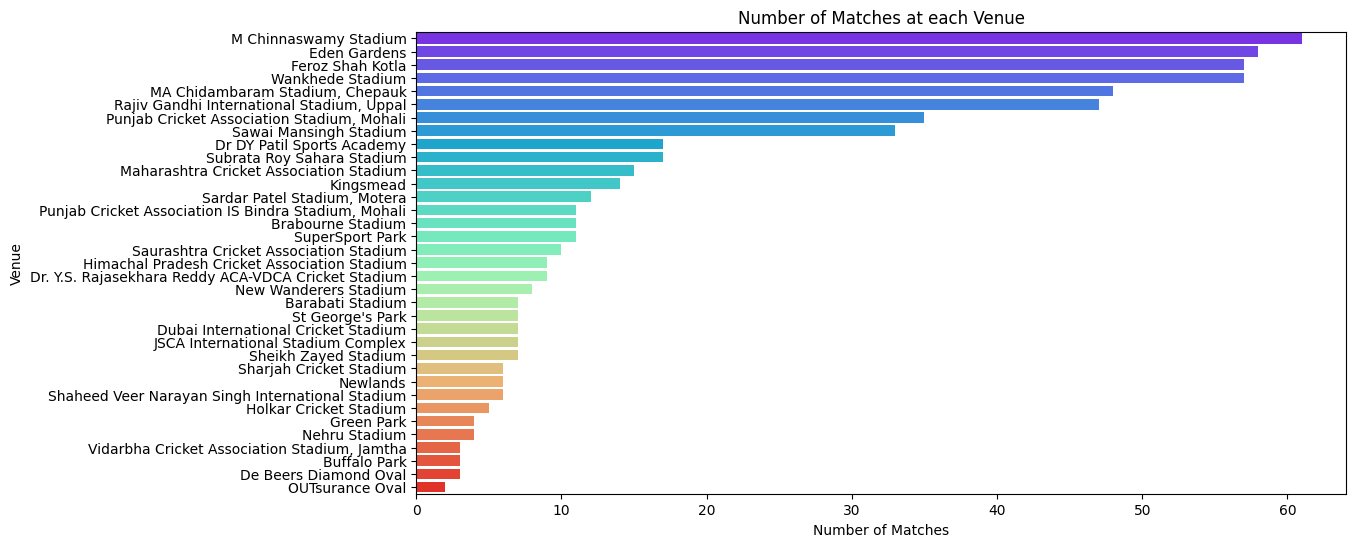

In [16]:
## how many unique matches are at each venue by distinct match IDs

data = ipl.copy()

matches_per_venue = data[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()


plt.figure(figsize= (12,6))
sns.barplot(x = matches_count.values, y=matches_count.index, palette='rainbow')
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.title("Number of Matches at each Venue")
plt.show()

#### Max run scored by each batsman



C:\Users\PANDIT JI\AppData\Local\Temp\ipykernel_12636\2388442922.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=runs_per_batsman.values, y=runs_per_batsman.index, palette='viridis')


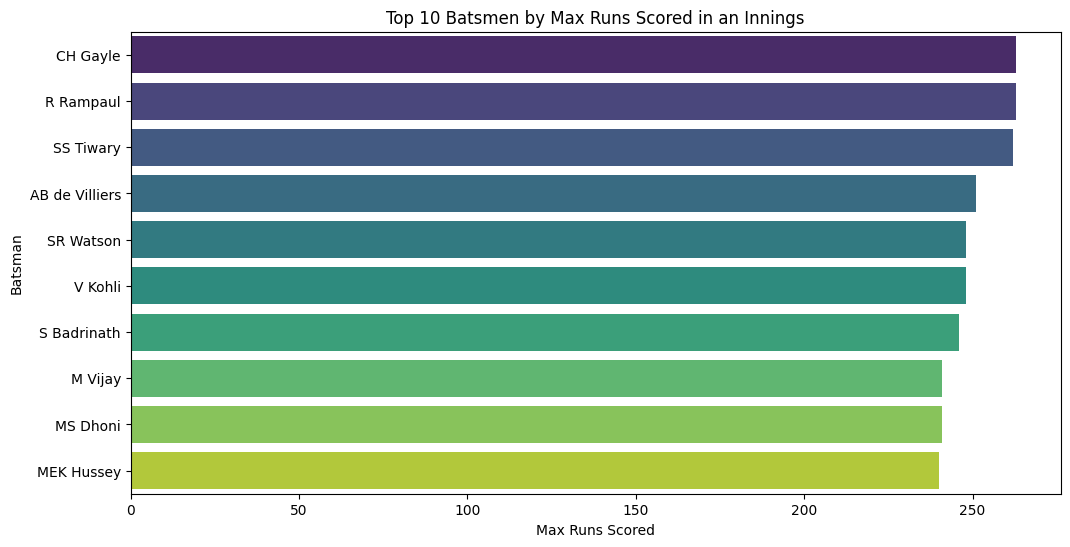

In [17]:
runs_per_batsman = data.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=runs_per_batsman.values, y=runs_per_batsman.index, palette='viridis')
plt.xlabel("Max Runs Scored")
plt.ylabel("Batsman")
plt.title("Top 10 Batsmen by Max Runs Scored in an Innings")
plt.show()

C:\Users\PANDIT JI\AppData\Local\Temp\ipykernel_12636\3950022217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wickets_by_bowler.values,


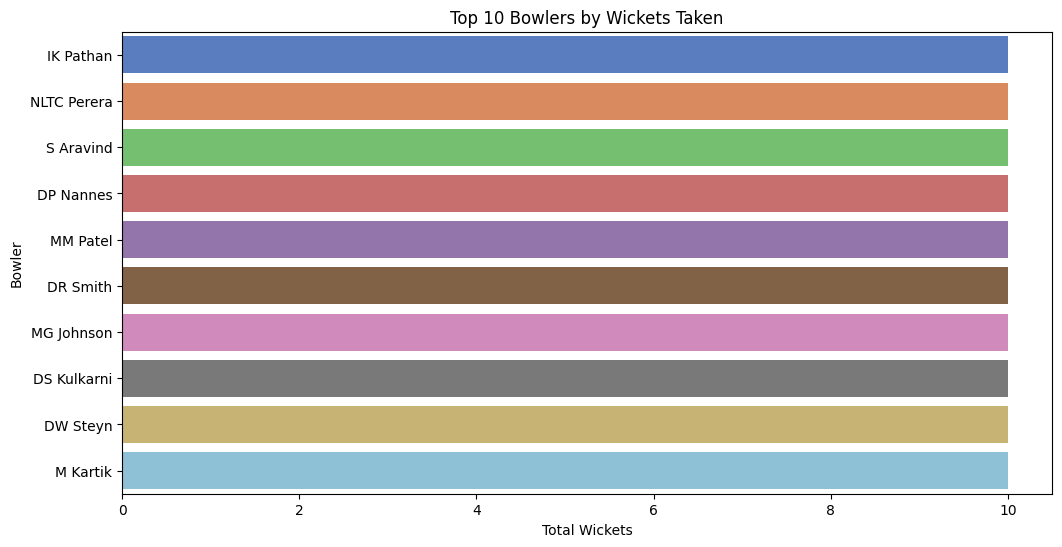

In [18]:
# For Bowlers

wickets_by_bowler = data.groupby(
    'bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_by_bowler.values,
            y=wickets_by_bowler.index, palette="muted")
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

In [19]:
ipl.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [20]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


## 4. Performing Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', 'batsman', 'bowler']

data_encoded = data.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

In [22]:
data.head(8)

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
5,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.5,2,0,0,0,222
6,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,3,0,0.6,3,0,0,0,222
7,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,3,0,1.1,3,0,0,0,222


In [23]:
data_encoded.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,14,6,12,328,201,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,14,6,12,61,201,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,14,6,12,61,201,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,14,6,12,61,201,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,14,6,12,61,201,2,0,0.4,2,0,0,0,222


## 5. Performing Feature Selection

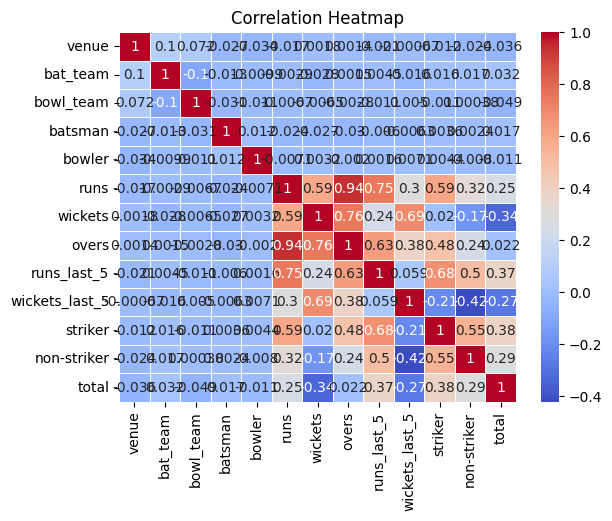

In [31]:
data_corr = data_encoded.drop(['date', 'mid'], axis=1)
sns.heatmap(data_corr.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## 6. Splitting the Dataset into Training and Testing

In [32]:
data_encoded.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [33]:
from sklearn.model_selection import train_test_split

feature_cols = ['bat_team', 'bowl_team', 'venue', 'batsman', 'bowler', 'wickets', 'overs', 'striker', 'runs']
X = data_encoded[feature_cols]
y = data_encoded['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## 7. Performing Feature Scaling

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1]:
data_encoded.head()

NameError: name 'data_encoded' is not defined

## 8. Building the Neural Network

* keras.Sequential() creates a stack of layers.
* Dense layers are fully connected layers.
* activation=relu adds non-linearity.
* Output layer uses linear activation because it’s regression.
* Huber loss combines MSE and MAE advantages to handle outliers better.
* adam optimizer adjusts weights efficiently.

In [35]:

import keras


model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(216, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

huber_loss = keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=huber_loss)

: 

## 9. Training the Model

In [ ]:
model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

In [ ]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

## 10. Evaluating the Model


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_scaled)

mean_absolute_error(y_test, predictions)

## 11. Creating an Interactive Widget for Score Prediction

* **widgets.Dropdown()** creates dropdown menus.
* **widgets.Button()** creates a clickable button.
* **predict_score()** function handles user inputs, encodes and scales them, runs prediction and displays result.
* **display()** shows widgets in the notebook.

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

venue = widgets.Dropdown(options=list(
    label_encoders['venue'].classes_), description='Select Venue:')
venue.style = {'description_width': 'initial'}

batting_team = widgets.Dropdown(options=list(
    label_encoders['bat_team'].classes_), description='Select Batting Team:')
batting_team.style = {'description_width': 'initial'}

bowling_team = widgets.Dropdown(options=list(
    label_encoders['bowl_team'].classes_), description='Select Bowling Team:')
bowling_team.style = {'description_width': 'initial'}

striker = widgets.Dropdown(options=list(
    label_encoders['batsman'].classes_), description='Select Striker:')
striker.style = {'description_width': 'initial'}

bowler = widgets.Dropdown(options=list(
    label_encoders['bowler'].classes_), description='Select Bowler:')
bowler.style = {'description_width': 'initial'}

runs = widgets.IntText(value=0, description='Runs:', style={
                       'description_width': 'initial'})
wickets = widgets.IntText(value=0, description='Wickets:', style={
                          'description_width': 'initial'})
overs = widgets.FloatText(value=0.0, description='Overs:', style={
                          'description_width': 'initial'})
striker_ind = widgets.IntText(value=0, description='Striker:', style={
                              'description_width': 'initial'})  # Assuming 0 or 1
predict_button = widgets.Button(description="Predict Score")

output = widgets.Output()


def predict_score(b):
    with output:
        clear_output()  # Clear previous output

        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform(
            [batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform(
            [bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform([striker.value])[
            0]
        encoded_bowler = label_encoders['bowler'].transform([bowler.value])[0]

        input_features = [
            encoded_batting_team,
            encoded_bowling_team,
            encoded_venue,
            runs.value,
            wickets.value,
            overs.value,
            striker_ind.value,
            encoded_striker,
            encoded_bowler
        ]

        input_array = np.array(input_features).reshape(1, -1)
        input_array = scaler.transform(input_array)
        predicted_score = model.predict(input_array)

        print(f"Predicted Total Runs: {int(predicted_score[0])}")


predict_button.on_click(predict_score)

display(venue, batting_team, bowling_team, striker, bowler,
        runs, wickets, overs,
        striker_ind,
        predict_button, output)